In [4]:
"""
Notebook-style analysis — paste each cell block into its own notebook cell.
Stratified by resolution (no collapsing).
"""

# ═══════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & config
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Import your dataloader ───────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname("../dataset.json"))
from dataloader import load_df, PARAMS, RESOLUTIONS


# -- adjust these paths --
DATA_PATH     = '../dataset.json'
FEATURES_PATH = 'video_stats.csv'

FOCUS_PARAMS   = ['alpha_weight', 'hist_percent']
FEATURE_COLS   = ['SI', 'TI', 'CF', 'TP', 'MV', 'DTP']
RESOLUTION_INT = [50, 71, 87, 100]
SCORE_COL      = 'score_centered'
CMAP_DIV       = 'RdBu_r'


In [5]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 2 — Load data
# ═══════════════════════════════════════════════════════════════════════
import sys, os
sys.path.insert(0, os.path.dirname("../dataset.json"))

from dataloader import load_df

df = load_df(DATA_PATH, center=True)

features_df = pd.read_csv(FEATURES_PATH)
features_df['scene'] = features_df['filename'].str.replace('.mp4', '', regex=False)
features_df = features_df.drop(columns=['filename', 'error'], errors='ignore')

print(f"Scenes: {df['scene'].nunique()}")
print(f"Features shape: {features_df.shape}")
print(features_df.head(3))

Scenes: 20
Features shape: (20, 7)
         SI        TI        CF        TP        MV        DTP  \
0  0.071411  0.032902  0.038091  0.007603  3.579346  25.403049   
1  0.150389  0.047368  0.027003  0.014857  5.690086  48.110163   
2  0.073039  0.015640  0.013338  0.007803  1.072247   5.741053   

               scene  
0     abandoned-demo  
1  abandoned-flipped  
2          abandoned  


In [6]:


# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — Step 1: Compute slope & sensitivity per scene x res x param
# ═══════════════════════════════════════════════════════════════════════

def compute_curve_stats(df, score_col=SCORE_COL):
    """
    For each (scene, resolution, parameter):
      - slope      : Spearman r between parameter values and CGVQM scores
      - sensitivity: max - min CGVQM
    """
    records = []
    for (scene, res, param), grp in df.groupby(['scene', 'resolution', 'parameter']):
        grp = grp.sort_values('value')
        vals   = grp['value'].values
        scores = grp[score_col].values
        if len(vals) < 3:
            continue
        r, _ = stats.spearmanr(vals, scores)
        sensitivity = scores.max() - scores.min()
        records.append({
            'scene':       scene,
            'resolution':  res,
            'parameter':   param,
            'slope':       r,
            'sensitivity': sensitivity,
            'n_values':    len(vals),
        })
    return pd.DataFrame(records)

curve_stats = compute_curve_stats(df)
print(curve_stats.groupby(['parameter', 'resolution'])[['slope', 'sensitivity']].mean().round(3))


                         slope  sensitivity
parameter    resolution                    
alpha_weight 50         -0.471        6.387
             71         -0.003        3.664
             87          0.360        2.790
             100         0.529        2.715
filter_size  50          0.064        0.130
             71          0.143        0.135
             87          0.057        0.154
             100         0.070        0.149
hist_percent 50         -0.010        1.464
             71          0.860        1.362
             87          0.930        1.428
             100         0.960        1.368
num_samples  50          0.075        0.159
             71         -0.015        0.157
             87          0.285        0.178
             100         0.375        0.289


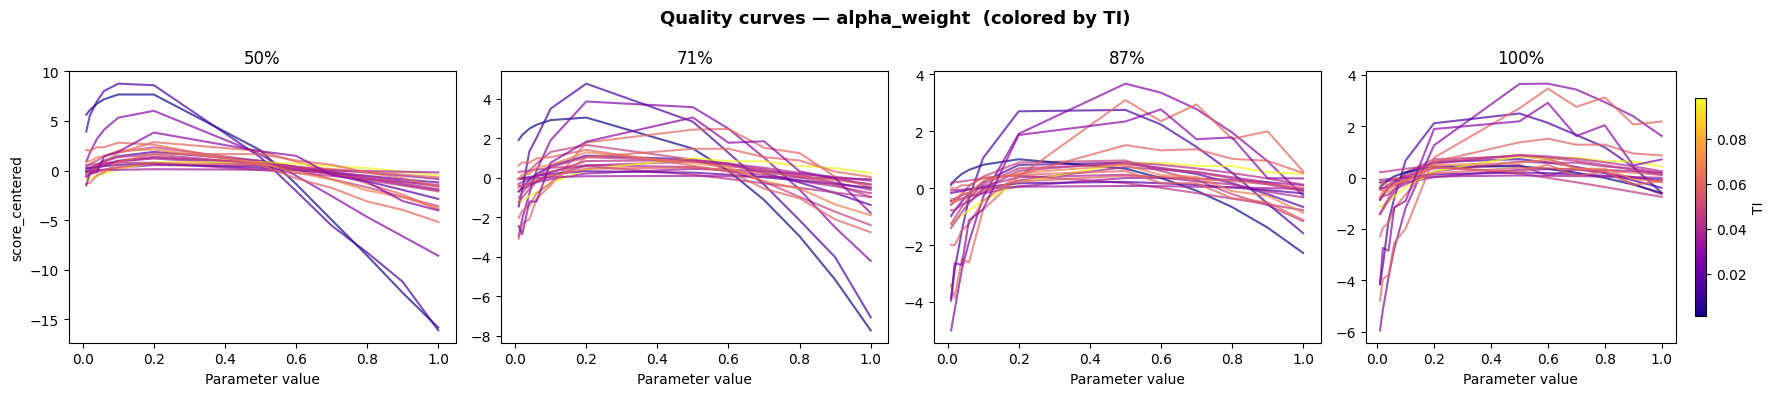

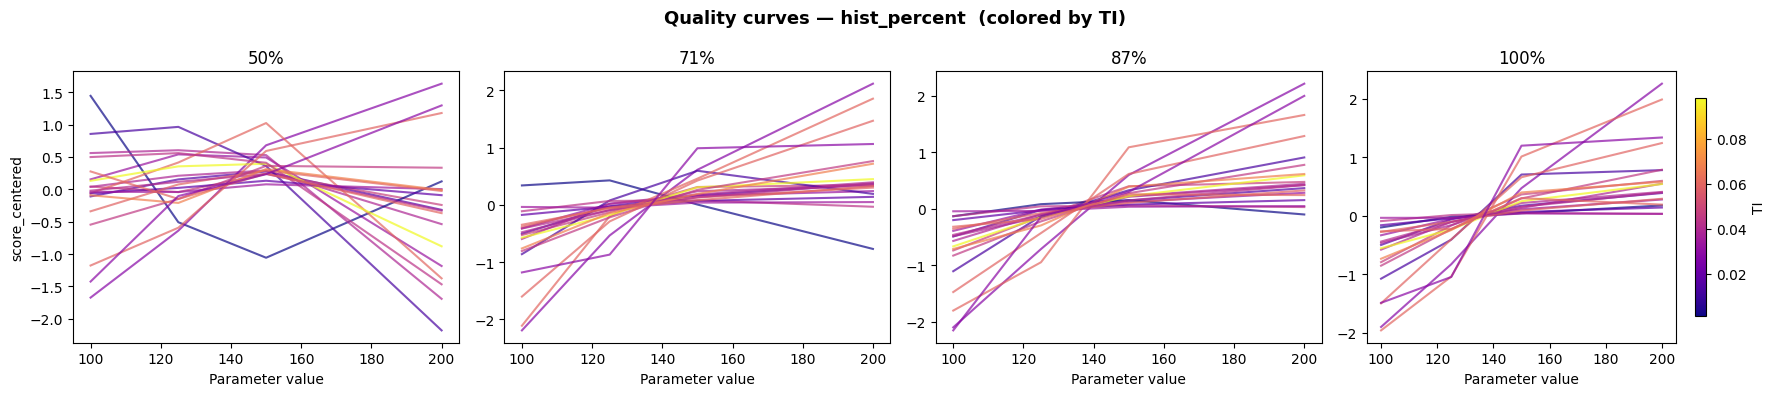

In [7]:


# ═══════════════════════════════════════════════════════════════════════
# CELL 4 — Step 2: Visualize quality curves (one param at a time)
# ═══════════════════════════════════════════════════════════════════════

def plot_quality_curves(df, features_df, param, score_col=SCORE_COL, color_feature='TI'):
    feat_vals = features_df.set_index('scene')[color_feature]
    norm = plt.Normalize(feat_vals.min(), feat_vals.max())
    cmap = plt.cm.plasma
    scenes = df['scene'].unique()

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
    fig.suptitle(f'Quality curves — {param}  (colored by {color_feature})',
                 fontsize=13, fontweight='bold')

    for ax, res in zip(axes, RESOLUTION_INT):
        sub = df[(df['parameter'] == param) & (df['resolution'] == res)]
        for scene in scenes:
            s = sub[sub['scene'] == scene].sort_values('value')
            if s.empty:
                continue
            color = cmap(norm(feat_vals.get(scene, np.nan)))
            ax.plot(s['value'], s[score_col], color=color, alpha=0.7, lw=1.5)
        ax.set_title(f'{res}%')
        ax.set_xlabel('Parameter value')
        if res == RESOLUTION_INT[0]:
            ax.set_ylabel(score_col)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[-1], label=color_feature, shrink=0.8)
    plt.tight_layout()
    plt.show()

# Change color_feature to any of FEATURE_COLS to re-color
plot_quality_curves(df, features_df, 'alpha_weight', color_feature='TI')
plot_quality_curves(df, features_df, 'hist_percent', color_feature='TI')



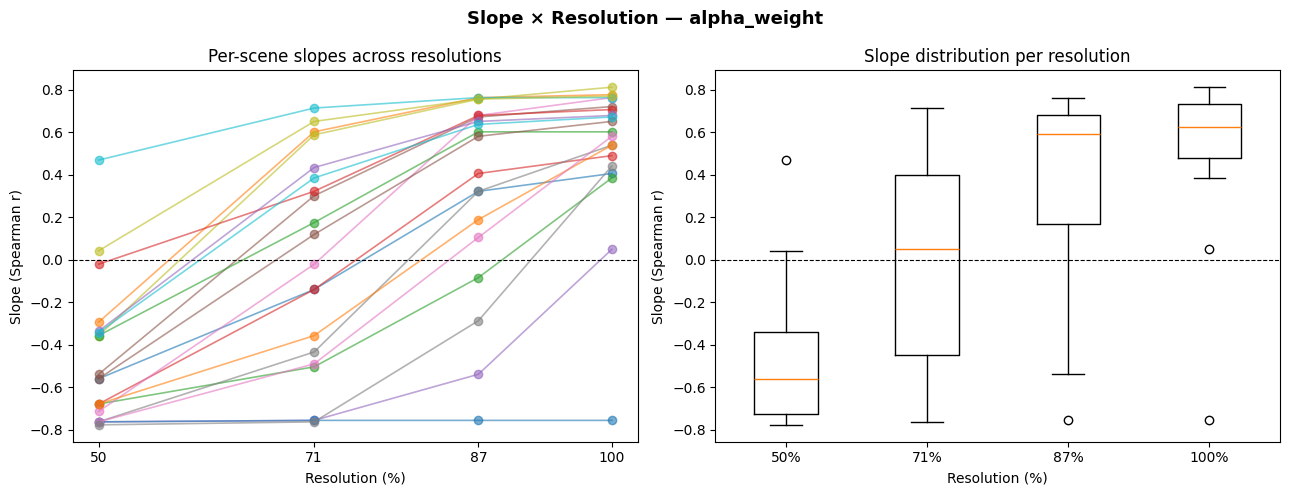

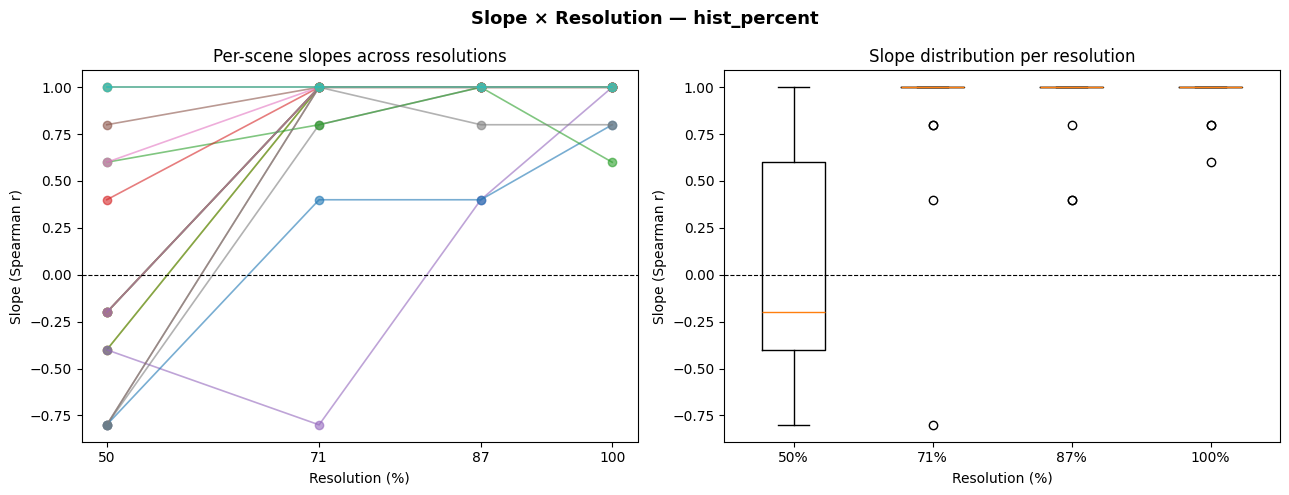

In [8]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 5 — Step 3: Slope × resolution (does direction flip?)
# ═══════════════════════════════════════════════════════════════════════

def plot_slope_vs_resolution(curve_stats, param):
    sub = curve_stats[curve_stats['parameter'] == param]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Slope × Resolution — {param}', fontsize=13, fontweight='bold')

    # Spaghetti
    ax = axes[0]
    for scene in sub['scene'].unique():
        s = sub[sub['scene'] == scene].sort_values('resolution')
        ax.plot(s['resolution'], s['slope'], marker='o', alpha=0.6, lw=1.2)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Resolution (%)')
    ax.set_ylabel('Slope (Spearman r)')
    ax.set_title('Per-scene slopes across resolutions')
    ax.set_xticks(RESOLUTION_INT)

    # Boxplot
    ax2 = axes[1]
    data = [sub[sub['resolution'] == r]['slope'].values for r in RESOLUTION_INT]
    ax2.boxplot(data, labels=[f'{r}%' for r in RESOLUTION_INT])
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    ax2.set_xlabel('Resolution (%)')
    ax2.set_ylabel('Slope (Spearman r)')
    ax2.set_title('Slope distribution per resolution')

    plt.tight_layout()
    plt.show()

plot_slope_vs_resolution(curve_stats, 'alpha_weight')
plot_slope_vs_resolution(curve_stats, 'hist_percent')


PC1: 65.6%  PC2: 18.4%


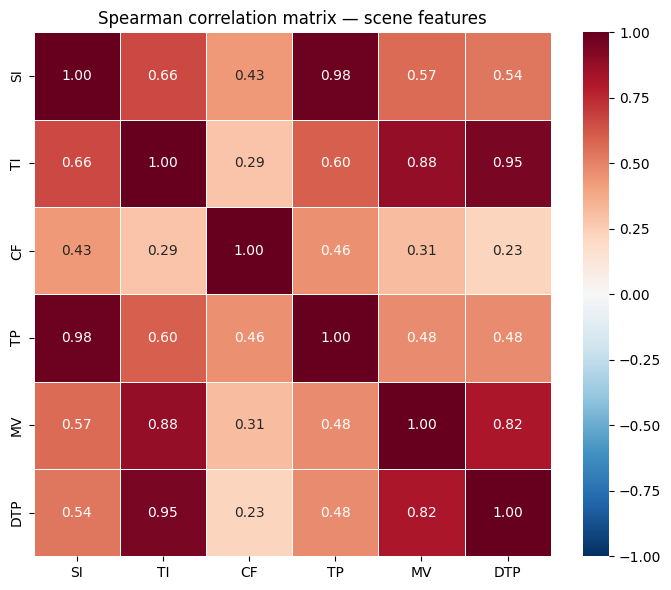

In [9]:


# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — Step 4a: PCA on scene features
# ═══════════════════════════════════════════════════════════════════════

feat = features_df.set_index('scene')[FEATURE_COLS].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat.values)
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

# Feature correlation matrix
fig, ax = plt.subplots(figsize=(7, 6))
corr_mat = pd.DataFrame(feat.values, columns=FEATURE_COLS).corr(method='spearman')
sns.heatmap(corr_mat, ax=ax, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Spearman correlation matrix — scene features')
plt.tight_layout()
plt.show()



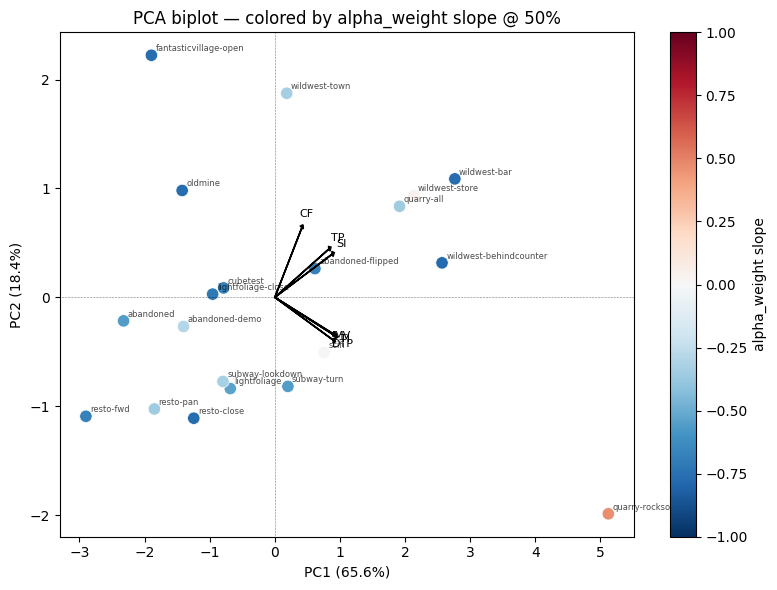

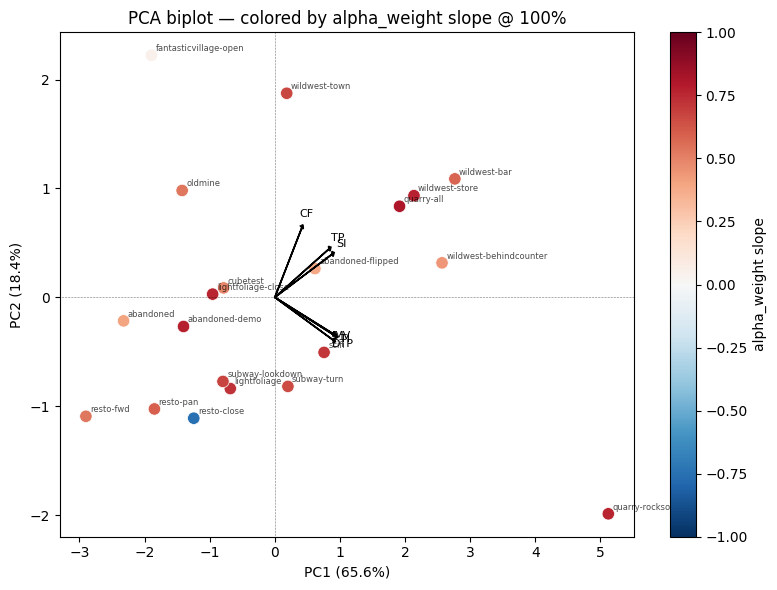

In [10]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 7 — Step 4b: PCA biplot (colored by slope at one resolution)
# ═══════════════════════════════════════════════════════════════════════

def plot_pca_biplot(curve_stats, feat, Z, pca, param, resolution):
    sub = curve_stats[
        (curve_stats['parameter'] == param) &
        (curve_stats['resolution'] == resolution)
    ].set_index('scene')

    common = feat.index.intersection(sub.index)
    Z_common = Z[feat.index.isin(common)]
    slopes = sub.loc[common, 'slope'].values

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(Z_common[:, 0], Z_common[:, 1],
                    c=slopes, cmap=CMAP_DIV, s=80,
                    edgecolors='white', lw=0.5, vmin=-1, vmax=1)
    for i, scene in enumerate(common):
        ax.annotate(scene, (Z_common[i, 0], Z_common[i, 1]),
                    fontsize=6, alpha=0.7, xytext=(3, 3),
                    textcoords='offset points')

    # Loadings
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    for j, fname in enumerate(FEATURE_COLS):
        ax.arrow(0, 0, loadings[j, 0], loadings[j, 1],
                 head_width=0.05, head_length=0.03,
                 fc='black', ec='black', lw=1.2)
        ax.text(loadings[j, 0] * 1.15, loadings[j, 1] * 1.15,
                fname, fontsize=8, ha='center')

    plt.colorbar(sc, ax=ax, label=f'{param} slope')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'PCA biplot — colored by {param} slope @ {resolution}%')
    ax.axhline(0, color='k', lw=0.4, ls=':')
    ax.axvline(0, color='k', lw=0.4, ls=':')
    plt.tight_layout()
    plt.show()

# Try different resolutions to see how the coloring changes
plot_pca_biplot(curve_stats, feat, Z, pca, param='alpha_weight', resolution=50)
plot_pca_biplot(curve_stats, feat, Z, pca, param='alpha_weight', resolution=100)


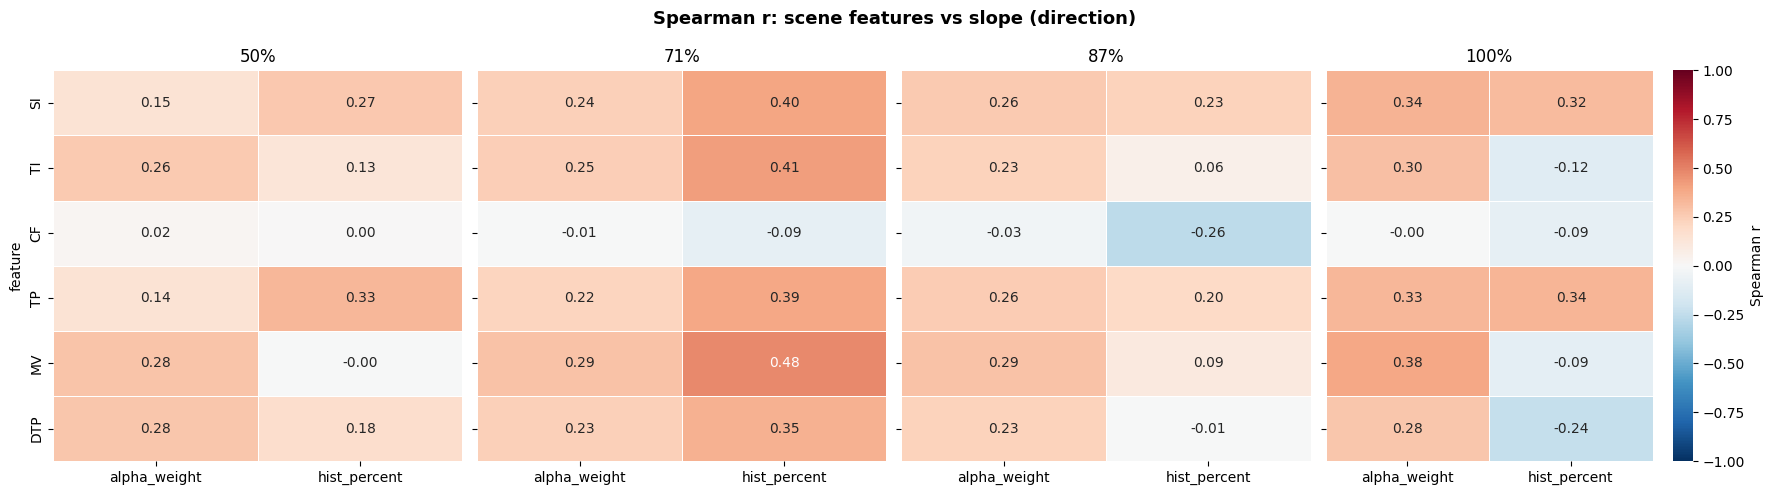

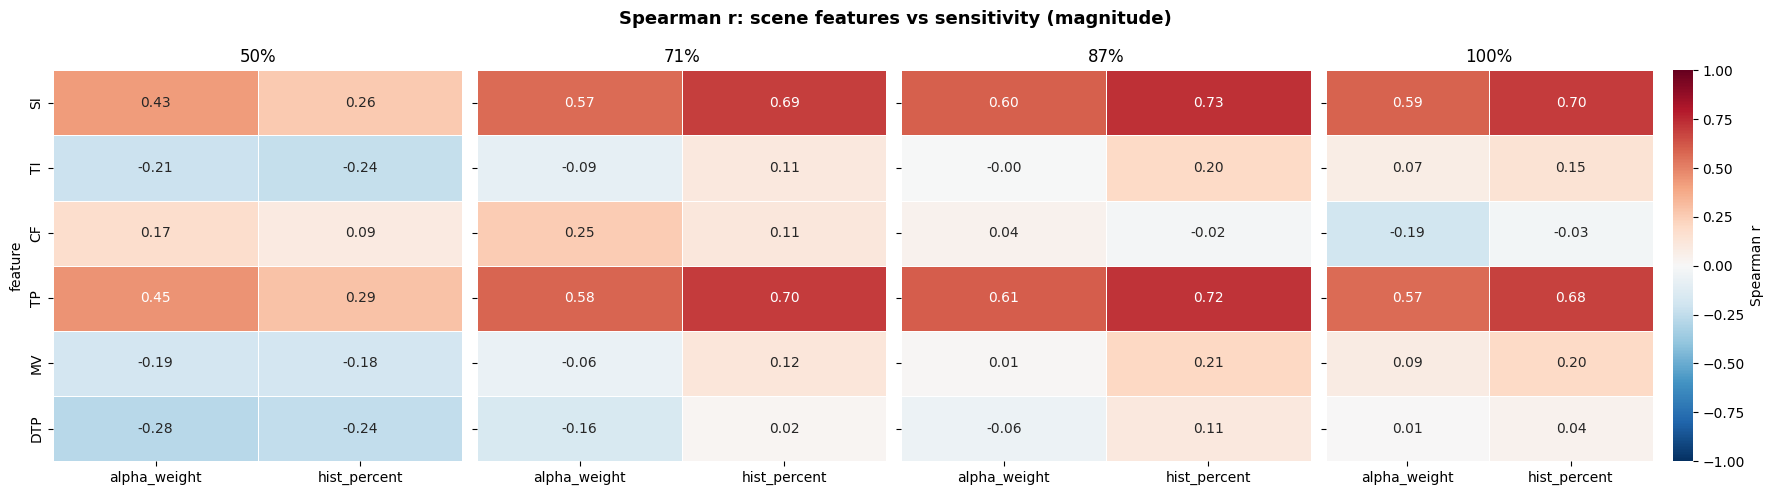

In [11]:


# ═══════════════════════════════════════════════════════════════════════
# CELL 8 — Step 4c: Correlation heatmap — stratified by resolution
# ═══════════════════════════════════════════════════════════════════════

def spearman_ci(x, y, n_boot=2000, ci=95):
    r, p = stats.spearmanr(x, y)
    rng = np.random.default_rng(42)
    boot_r = [
        stats.spearmanr(
            x[idx := rng.integers(0, len(x), len(x))],
            y[idx]
        )[0]
        for _ in range(n_boot)
    ]
    lo, hi = np.percentile(boot_r, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return r, p, lo, hi


def compute_correlations(curve_stats, features_df):
    """Spearman r between each feature and (slope, sensitivity) per param x resolution."""
    feat = features_df.set_index('scene')[FEATURE_COLS]
    records = []
    for param in FOCUS_PARAMS:
        for res in RESOLUTION_INT:
            sub = curve_stats[
                (curve_stats['parameter'] == param) &
                (curve_stats['resolution'] == res)
            ].set_index('scene')
            for target in ['slope', 'sensitivity']:
                for feat_col in FEATURE_COLS:
                    common = feat.index.intersection(sub.index)
                    x = feat.loc[common, feat_col].values
                    y = sub.loc[common, target].values
                    r, p, lo, hi = spearman_ci(x, y)
                    records.append({
                        'parameter':  param,
                        'resolution': res,
                        'target':     target,
                        'feature':    feat_col,
                        'r':          r,
                        'p':          p,
                        'ci_lo':      lo,
                        'ci_hi':      hi,
                    })
    return pd.DataFrame(records)

corr_df = compute_correlations(curve_stats, features_df)


def plot_correlation_heatmaps(corr_df, target='slope'):
    """
    4-panel heatmap (one per resolution): features × parameters.
    """
    sub = corr_df[corr_df['target'] == target]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
    fig.suptitle(
        f'Spearman r: scene features vs {"slope (direction)" if target == "slope" else "sensitivity (magnitude)"}',
        fontsize=13, fontweight='bold'
    )
    for ax, res in zip(axes, RESOLUTION_INT):
        pivot = (
            sub[sub['resolution'] == res]
            .pivot(index='feature', columns='parameter', values='r')
            .reindex(FEATURE_COLS)[FOCUS_PARAMS]
        )
        sns.heatmap(
            pivot, ax=ax, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar=(res == RESOLUTION_INT[-1]),
            cbar_kws={'label': 'Spearman r'} if res == RESOLUTION_INT[-1] else {}
        )
        ax.set_title(f'{res}%')
        ax.set_xlabel('')
        if res != RESOLUTION_INT[0]:
            ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

plot_correlation_heatmaps(corr_df, target='slope')
plot_correlation_heatmaps(corr_df, target='sensitivity')


In [ ]:


# ═══════════════════════════════════════════════════════════════════════
# CELL 9 — Step 5: Scatter plots for strong correlations
# ═══════════════════════════════════════════════════════════════════════

def plot_scatter_strong(curve_stats, features_df, corr_df, threshold=0.35):
    feat = features_df.set_index('scene')[FEATURE_COLS]
    strong = corr_df[corr_df['r'].abs() >= threshold].copy()

    if strong.empty:
        print(f"No correlations above |r| = {threshold}")
        return

    for _, row in strong.iterrows():
        sub = curve_stats[
            (curve_stats['parameter'] == row['parameter']) &
            (curve_stats['resolution'] == row['resolution'])
        ].set_index('scene')

        common = feat.index.intersection(sub.index)
        x = feat.loc[common, row['feature']].values
        y = sub.loc[common, row['target']].values
        scenes = common.values

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.scatter(x, y, s=60, alpha=0.8, color='steelblue',
                   edgecolors='white', lw=0.5)
        for xi, yi, sc in zip(x, y, scenes):
            ax.annotate(sc, (xi, yi), fontsize=6, alpha=0.6,
                        xytext=(3, 3), textcoords='offset points')

        m, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 100)
        ax.plot(xr, m * xr + b, color='tomato', lw=1.5, ls='--')
        ax.axhline(0, color='k', lw=0.6, ls=':')

        target_label = 'slope' if row['target'] == 'slope' else 'sensitivity'
        ax.set_xlabel(row['feature'])
        ax.set_ylabel(f"{target_label}")
        ax.set_title(
            f"{row['feature']} vs {target_label}\n"
            f"{row['parameter']} @ {row['resolution']}%  "
            f"r={row['r']:.2f}  95% CI [{row['ci_lo']:.2f}, {row['ci_hi']:.2f}]"
        )
        plt.tight_layout()
        plt.show()

plot_scatter_strong(curve_stats, features_df, corr_df, threshold=0.35)


# ═══════════════════════════════════════════════════════════════════════
# CELL 10 — Step 6: Hierarchical clustering
# Uses slopes at all resolutions as the feature vector per scene
# ═══════════════════════════════════════════════════════════════════════

# Build 20 x 8 matrix: (alpha_weight slope @ 4 res) + (hist_percent slope @ 4 res)
slope_pivot = curve_stats[curve_stats['parameter'].isin(FOCUS_PARAMS)].pivot_table(
    index='scene',
    columns=['parameter', 'resolution'],
    values='slope'
).dropna()

Z_link = linkage(slope_pivot.values, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hierarchical clustering by slope profile (all resolutions)',
             fontsize=13, fontweight='bold')

# Dendrogram
dendrogram(Z_link, labels=slope_pivot.index.tolist(), ax=axes[0],
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z_link[:, 2]))
axes[0].set_title('Dendrogram')
axes[0].set_ylabel('Ward distance')

# Scatter: alpha_weight slope vs hist_percent slope at 50% (most informative res)
k = 3
labels = fcluster(Z_link, k, criterion='maxclust')
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

aw_50  = curve_stats[(curve_stats['parameter'] == 'alpha_weight') & (curve_stats['resolution'] == 50)].set_index('scene')
hp_50  = curve_stats[(curve_stats['parameter'] == 'hist_percent')  & (curve_stats['resolution'] == 50)].set_index('scene')
common = slope_pivot.index

for cl in range(1, k + 1):
    idx = slope_pivot.index[labels == cl]
    axes[1].scatter(
        aw_50.loc[idx, 'slope'],
        hp_50.loc[idx, 'slope'],
        s=80, label=f'Cluster {cl}',
        color=palette[cl - 1], edgecolors='white', lw=0.5
    )
for scene in common:
    axes[1].annotate(scene,
                     (aw_50.loc[scene, 'slope'], hp_50.loc[scene, 'slope']),
                     fontsize=5, alpha=0.6,
                     xytext=(3, 3), textcoords='offset points')

axes[1].axhline(0, color='k', lw=0.6, ls=':')
axes[1].axvline(0, color='k', lw=0.6, ls=':')
axes[1].set_xlabel('alpha_weight slope @ 50%')
axes[1].set_ylabel('hist_percent slope @ 50%')
axes[1].set_title(f'Slope profile (k={k} clusters, shown at 50%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Cluster membership
for cl in range(1, k + 1):
    members = slope_pivot.index[labels == cl].tolist()
    print(f"Cluster {cl}: {members}")